<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Before-your-start:" data-toc-modified-id="Before-your-start:-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Before your start:</a></span></li><li><span><a href="#Challenge-1---Import-and-Describe-the-Dataset" data-toc-modified-id="Challenge-1---Import-and-Describe-the-Dataset-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Challenge 1 - Import and Describe the Dataset</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?" data-toc-modified-id="Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?-2.0.0.1"><span class="toc-item-num">2.0.0.1&nbsp;&nbsp;</span>Explore the dataset with mathematical and visualization techniques. What do you find?</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-2---Data-Cleaning-and-Transformation" data-toc-modified-id="Challenge-2---Data-Cleaning-and-Transformation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Challenge 2 - Data Cleaning and Transformation</a></span></li><li><span><a href="#Challenge-3---Data-Preprocessing" data-toc-modified-id="Challenge-3---Data-Preprocessing-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Challenge 3 - Data Preprocessing</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here." data-toc-modified-id="We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here.-4.0.0.1"><span class="toc-item-num">4.0.0.1&nbsp;&nbsp;</span>We will use the <code>StandardScaler</code> from <code>sklearn.preprocessing</code> and scale our data. Read more about <code>StandardScaler</code> <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler" target="_blank">here</a>.</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-4---Data-Clustering-with-K-Means" data-toc-modified-id="Challenge-4---Data-Clustering-with-K-Means-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Challenge 4 - Data Clustering with K-Means</a></span></li><li><span><a href="#Challenge-5---Data-Clustering-with-DBSCAN" data-toc-modified-id="Challenge-5---Data-Clustering-with-DBSCAN-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Challenge 5 - Data Clustering with DBSCAN</a></span></li><li><span><a href="#Challenge-6---Compare-K-Means-with-DBSCAN" data-toc-modified-id="Challenge-6---Compare-K-Means-with-DBSCAN-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Challenge 6 - Compare K-Means with DBSCAN</a></span></li><li><span><a href="#Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters" data-toc-modified-id="Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Bonus Challenge 2 - Changing K-Means Number of Clusters</a></span></li><li><span><a href="#Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples" data-toc-modified-id="Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Bonus Challenge 3 - Changing DBSCAN <code>eps</code> and <code>min_samples</code></a></span></li></ul></div>

# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [1]:
# Import your libraries:

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings                                              
from sklearn.exceptions import DataConversionWarning          
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

# Challenge 1 - Import and Describe the Dataset

In this lab, we will use a dataset containing information about customer preferences. We will look at how much each customer spends in a year on each subcategory in the grocery store and try to find similarities using clustering.

The origin of the dataset is [here](https://archive.ics.uci.edu/ml/datasets/wholesale+customers).

In [2]:
customers = pd.read_csv('../data/Wholesale customers data.csv')
customers.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


#### Explore the dataset with mathematical and visualization techniques. What do you find?

Checklist:

* What does each column mean?
* Any categorical data to convert?
* Any missing data to remove?
* Column collinearity - any high correlations?
* Descriptive statistics - any outliers to remove?
* Column-wise data distribution - is the distribution skewed?
* Etc.

Additional info: Over a century ago, an Italian economist named Vilfredo Pareto discovered that roughly 20% of the customers account for 80% of the typical retail sales. This is called the [Pareto principle](https://en.wikipedia.org/wiki/Pareto_principle). Check if this dataset displays this characteristic.

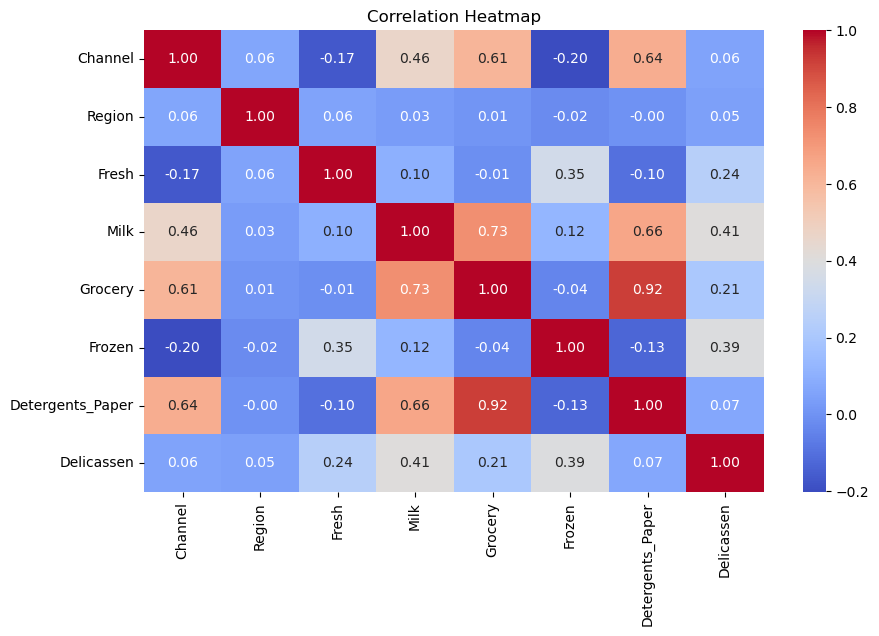

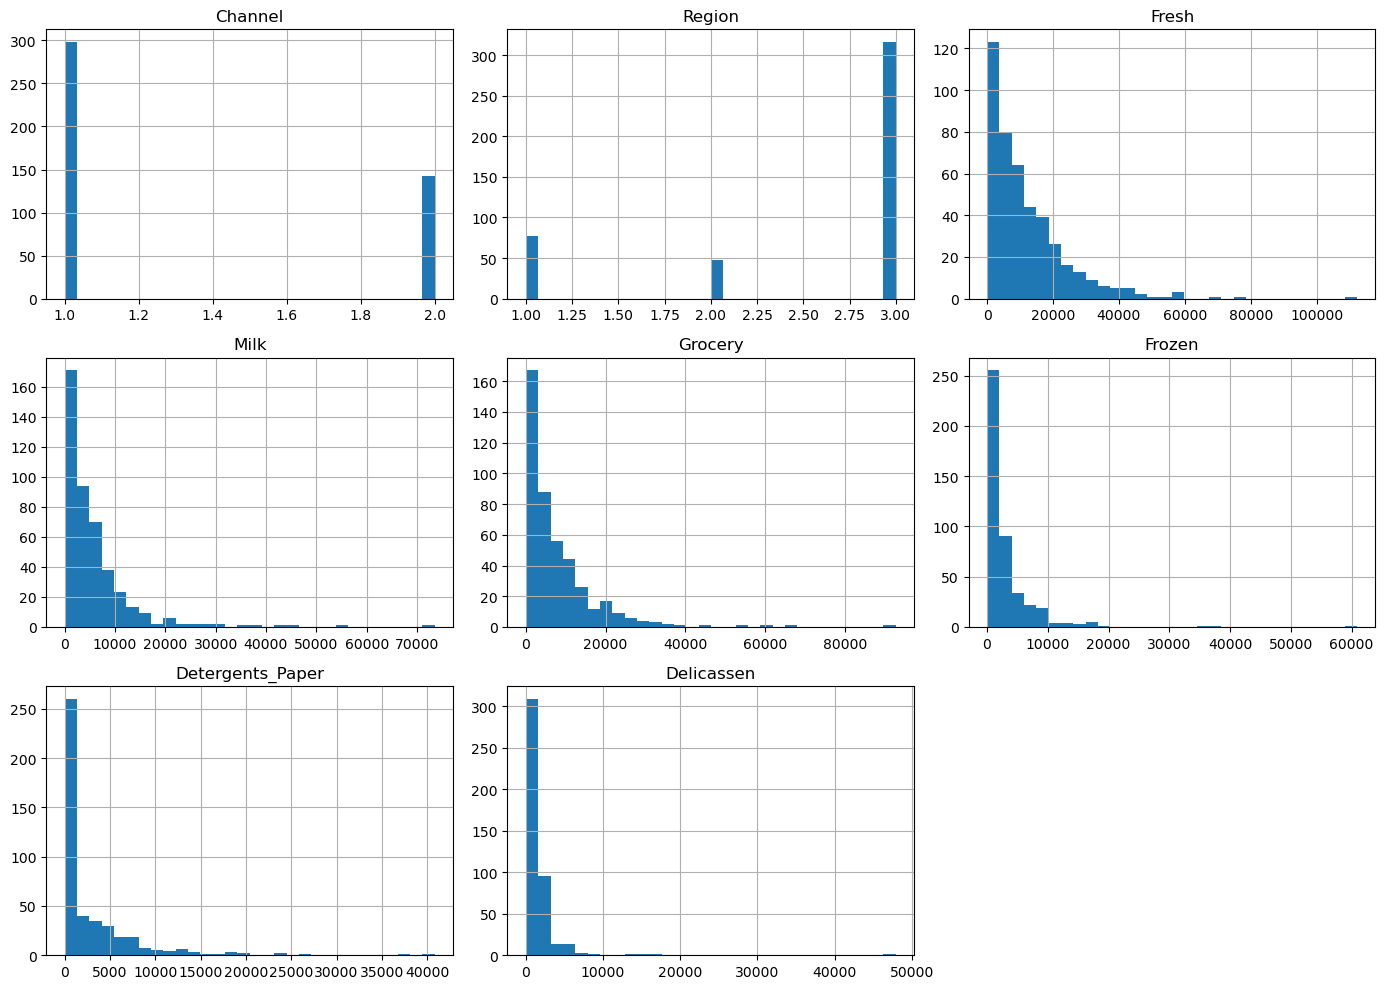

Detergents_Paper    0.697066
Frozen              0.623814
Delicassen          0.573894
Milk                0.560542
Grocery             0.556874
Fresh               0.526733
Channel             0.302405
Region              0.235925
dtype: float64

In [3]:
customers.shape
customers.head()
customers.describe().T
customers.isna().sum()
customers.duplicated().sum()

plt.figure(figsize=(10, 6))
sns.heatmap(customers.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

customers.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

pareto_share = {}
top_n = int(np.ceil(len(customers) * 0.2))
for col in customers.columns:
    sorted_values = customers[col].sort_values(ascending=False)
    pareto_share[col] = sorted_values.head(top_n).sum() / sorted_values.sum()

pd.Series(pareto_share).sort_values(ascending=False)

**Your observations here**

- The dataset has 440 rows and 8 numeric columns. `Channel` and `Region` are encoded categories, while the other columns are annual spending amounts.
- There are no missing values and no duplicated rows, so we do not need to drop records for data quality reasons.
- Several spending columns are right-skewed and contain large outliers, especially `Fresh`, `Frozen`, `Detergents_Paper`, and `Delicassen`.
- `Grocery`, `Milk`, and `Detergents_Paper` are strongly positively correlated, which suggests a common purchasing pattern for some customer groups.
- The Pareto principle appears in the spending variables: the top 20% of customers account for well over 50% of spending in several categories, and almost 70% for `Detergents_Paper`.
- Because the feature scales are very different, scaling is necessary before clustering so large-spend columns do not dominate the distance calculations.


# Challenge 2 - Data Cleaning and Transformation

If your conclusion from the previous challenge is the data need cleaning/transformation, do it in the cells below. However, if your conclusion is the data need not be cleaned or transformed, feel free to skip this challenge. But if you do choose the latter, please provide rationale.

In [5]:
clean_customers = customers.copy()
clean_customers.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


**Your comment here**

- I kept all rows because there are no missing values or duplicates in the dataset.
- I did not remove outliers at this stage because they may represent real high-value wholesale customers rather than data errors.
- I kept the original columns and will rely on feature scaling in the next step to make the clustering less sensitive to differences in magnitude.


# Challenge 3 - Data Preprocessing

One problem with the dataset is the value ranges are remarkably different across various categories (e.g. `Fresh` and `Grocery` compared to `Detergents_Paper` and `Delicassen`). If you made this observation in the first challenge, you've done a great job! This means you not only completed the bonus questions in the previous Supervised Learning lab but also researched deep into [*feature scaling*](https://en.wikipedia.org/wiki/Feature_scaling). Keep on the good work!

Diverse value ranges in different features could cause issues in our clustering. The way to reduce the problem is through feature scaling. We'll use this technique again with this dataset.

#### We will use the `StandardScaler` from `sklearn.preprocessing` and scale our data. Read more about `StandardScaler` [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

*After scaling your data, assign the transformed data to a new variable `customers_scale`.*

In [6]:
# Your import here:

from sklearn.preprocessing import StandardScaler

# Your code here:
scaler = StandardScaler()
customers_scale = scaler.fit_transform(clean_customers)
customers_scale[:5]

array([[ 1.44865163,  0.59066829,  0.05293319,  0.52356777, -0.04111489,
        -0.58936716, -0.04356873, -0.06633906],
       [ 1.44865163,  0.59066829, -0.39130197,  0.54445767,  0.17031835,
        -0.27013618,  0.08640684,  0.08915105],
       [ 1.44865163,  0.59066829, -0.44702926,  0.40853771, -0.0281571 ,
        -0.13753572,  0.13323164,  2.24329255],
       [-0.69029709,  0.59066829,  0.10011141, -0.62401993, -0.3929769 ,
         0.6871443 , -0.49858822,  0.09341105],
       [ 1.44865163,  0.59066829,  0.84023948, -0.05239645, -0.07935618,
         0.17385884, -0.23191782,  1.29934689]])

# Challenge 4 - Data Clustering with K-Means

Now let's cluster the data with K-Means first. Initiate the K-Means model, then fit your scaled data. In the data returned from the `.fit` method, there is an attribute called `labels_` which is the cluster number assigned to each data record. What you can do is to assign these labels back to `customers` in a new column called `customers['labels']`. Then you'll see the cluster results of the original data.

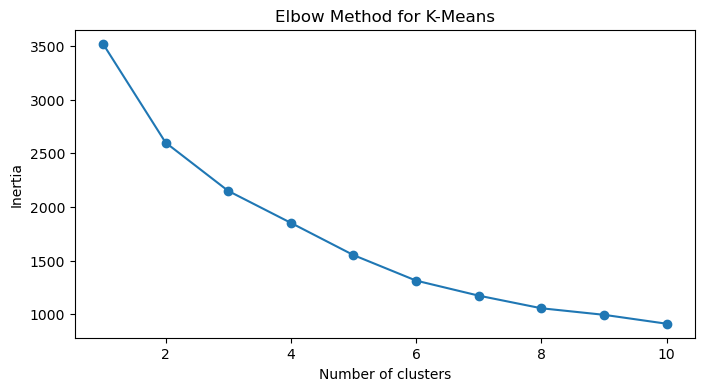

In [7]:
from sklearn.cluster import KMeans

# Your code here:
inertia = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(customers_scale)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')
plt.show()

### Looking to the elbow we can choose 2 like the correct number of clusters

In [8]:
kmeans_2 = KMeans(n_clusters=2).fit(customers_scale)

labels = kmeans_2.predict(customers_scale)

clusters = kmeans_2.labels_.tolist()

In [10]:
clean_customers['Label'] = clusters

Count the values in `labels`.

In [11]:
clean_customers['Label'].value_counts().sort_index()

Label
0    334
1    106
Name: count, dtype: int64

# Challenge 5 - Data Clustering with DBSCAN

Now let's cluster the data using DBSCAN. Use `DBSCAN(eps=0.5)` to initiate the model, then fit your scaled data. In the data returned from the `.fit` method, assign the `labels_` back to `customers['labels_DBSCAN']`. Now your original data have two labels, one from K-Means and the other from DBSCAN.

In [12]:
from sklearn.cluster import DBSCAN 

# Your code here
dbscan = DBSCAN(eps=0.5)
dbscan.fit(customers_scale)
clean_customers['labels_DBSCAN'] = dbscan.labels_
clean_customers[['Label', 'labels_DBSCAN']].head()

,Label,labels_DBSCAN
0,0,-1
1,0,-1
2,0,-1
3,0,1
4,0,-1


Count the values in `labels_DBSCAN`.

In [13]:
clean_customers['labels_DBSCAN'].value_counts().sort_index()

labels_DBSCAN
-1    255
 0      5
 1    130
 2      5
 3      5
 4      7
 5     22
 6      6
 7      5
Name: count, dtype: int64

# Challenge 6 - Compare K-Means with DBSCAN

Now we want to visually compare how K-Means and DBSCAN have clustered our data. We will create scatter plots for several columns. For each of the following column pairs, plot a scatter plot using `labels` and another using `labels_DBSCAN`. Put them side by side to compare. Which clustering algorithm makes better sense?

Columns to visualize:

* `Detergents_Paper` as X and `Milk` as y
* `Grocery` as X and `Fresh` as y
* `Frozen` as X and `Delicassen` as y

Visualize `Detergents_Paper` as X and `Milk` as y by `labels` and `labels_DBSCAN` respectively

In [14]:
def plot(x,y,hue):
    sns.scatterplot(x=x, 
                    y=y,
                    hue=hue)
    plt.title('Detergents Paper vs Milk ')
    return plt.show();

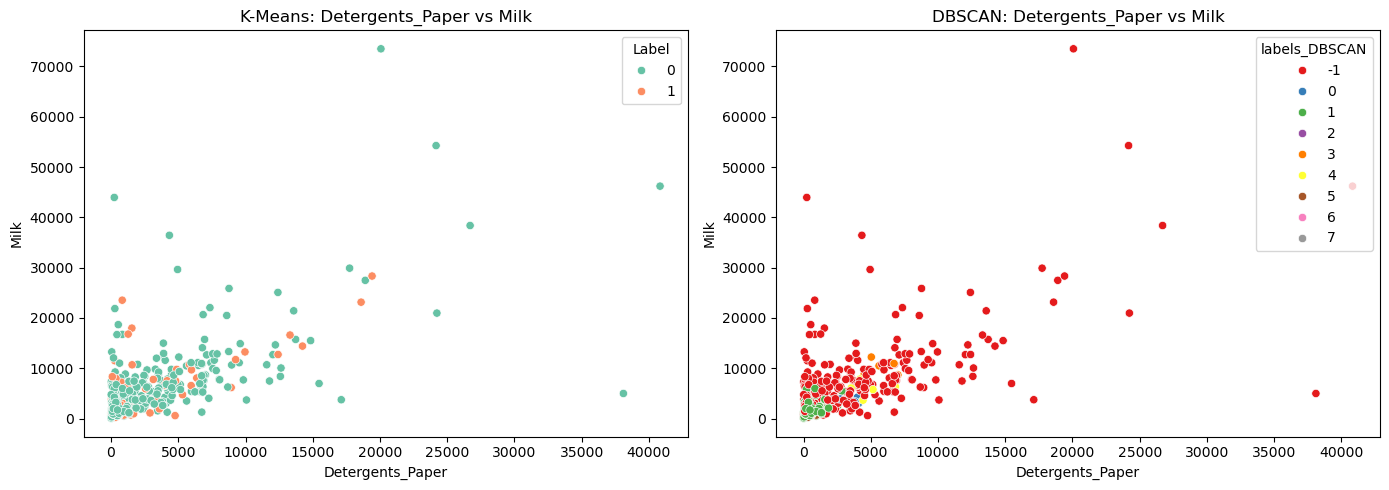

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=clean_customers, x='Detergents_Paper', y='Milk', hue='Label', palette='Set2', ax=axes[0])
axes[0].set_title('K-Means: Detergents_Paper vs Milk')
sns.scatterplot(data=clean_customers, x='Detergents_Paper', y='Milk', hue='labels_DBSCAN', palette='Set1', ax=axes[1])
axes[1].set_title('DBSCAN: Detergents_Paper vs Milk')
plt.tight_layout()
plt.show()

Visualize `Grocery` as X and `Fresh` as y by `labels` and `labels_DBSCAN` respectively

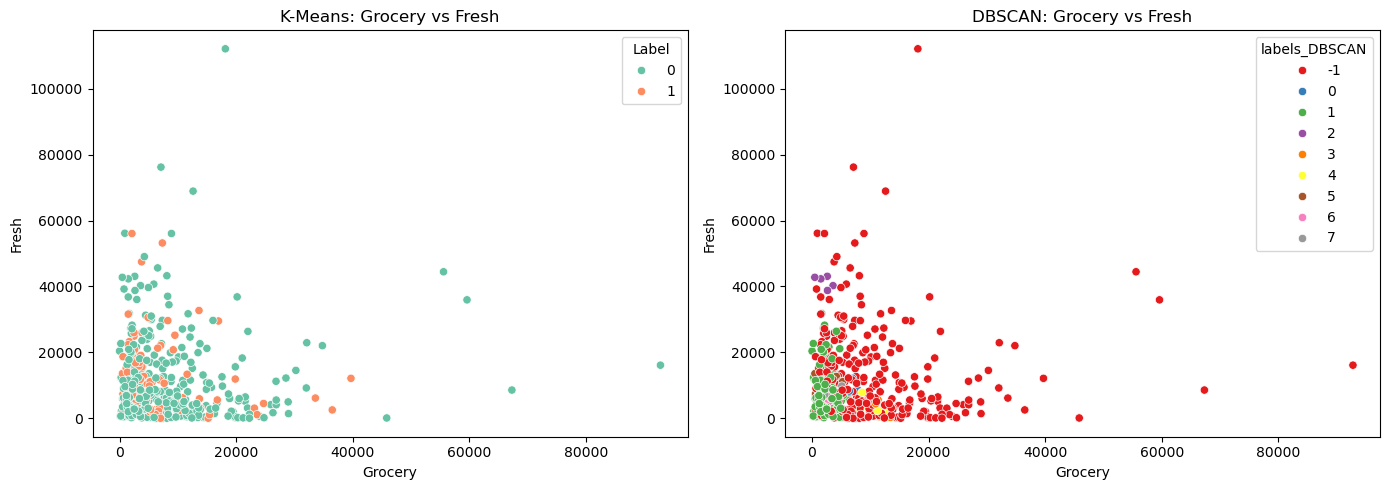

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=clean_customers, x='Grocery', y='Fresh', hue='Label', palette='Set2', ax=axes[0])
axes[0].set_title('K-Means: Grocery vs Fresh')
sns.scatterplot(data=clean_customers, x='Grocery', y='Fresh', hue='labels_DBSCAN', palette='Set1', ax=axes[1])
axes[1].set_title('DBSCAN: Grocery vs Fresh')
plt.tight_layout()
plt.show()

Visualize `Frozen` as X and `Delicassen` as y by `labels` and `labels_DBSCAN` respectively

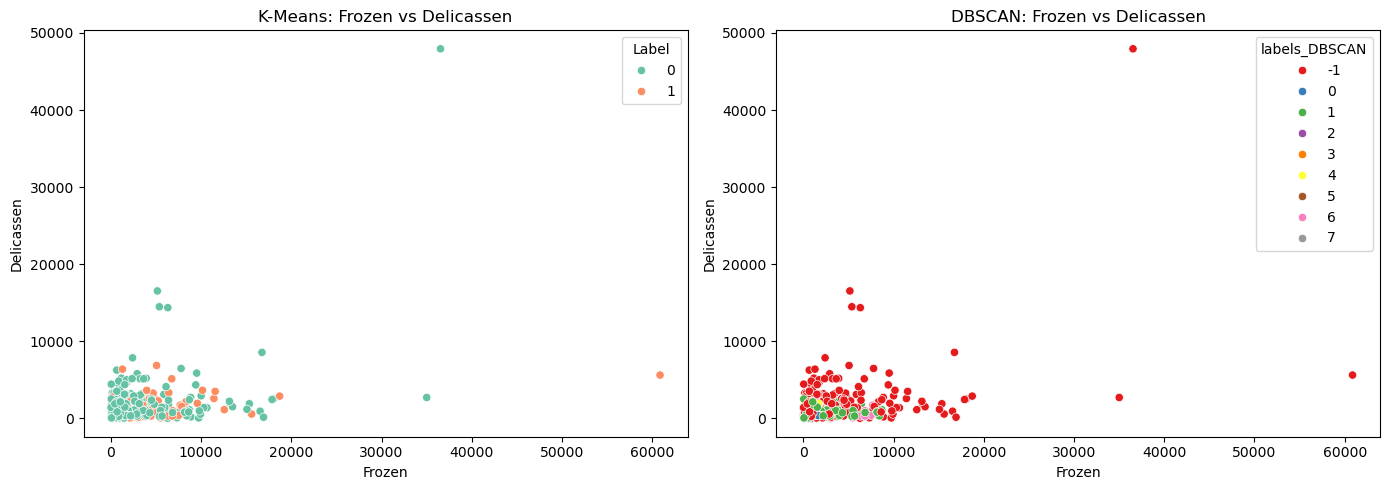

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=clean_customers, x='Frozen', y='Delicassen', hue='Label', palette='Set2', ax=axes[0])
axes[0].set_title('K-Means: Frozen vs Delicassen')
sns.scatterplot(data=clean_customers, x='Frozen', y='Delicassen', hue='labels_DBSCAN', palette='Set1', ax=axes[1])
axes[1].set_title('DBSCAN: Frozen vs Delicassen')
plt.tight_layout()
plt.show()

Let's use a groupby to see how the mean differs between the groups. Group `customers` by `labels` and `labels_DBSCAN` respectively and compute the means for all columns.

In [18]:
kmeans_group_means = clean_customers.groupby('Label').mean()
dbscan_group_means = clean_customers.groupby('labels_DBSCAN').mean()

kmeans_group_means
dbscan_group_means

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Label
labels_DBSCAN,,,,,,,,,
-1,1.490196,2.45098,13729.564706,8359.886275,11484.364706,3795.003922,4356.800000,2080.470588,0.286275
0,2.000000,3.00000,11401.000000,3536.200000,6729.000000,720.200000,3561.000000,258.200000,0.000000
1,1.000000,3.00000,9128.823077,1862.438462,2423.530769,2131.430769,496.576923,741.946154,0.000000
2,1.000000,3.00000,41446.600000,1421.200000,2167.600000,1276.400000,416.200000,784.800000,0.000000
3,2.000000,3.00000,2357.200000,10224.800000,11862.800000,609.600000,5780.000000,572.800000,0.000000
4,2.000000,3.00000,3068.142857,6095.857143,10355.000000,994.000000,4675.571429,1826.428571,0.000000
5,1.000000,1.00000,9837.863636,1751.863636,2161.681818,1513.181818,333.954545,669.045455,1.000000
6,1.000000,1.00000,6823.000000,1943.000000,2372.666667,6780.333333,386.500000,613.666667,1.000000
7,1.000000,2.00000,7494.600000,1537.600000,3383.000000,2575.400000,227.400000,941.000000,1.000000


Which algorithm appears to perform better?

**Your observations here**

- K-Means produces two clear customer groups with reasonably balanced sizes, so it is easier to interpret in this dataset.
- With `eps=0.5`, DBSCAN labels most points as noise, which suggests the default density threshold is too strict after scaling.
- In the scatter plots, K-Means gives more consistent segmentation across the spending features, while DBSCAN mostly isolates a few dense pockets and leaves the rest unclustered.
- For this notebook, K-Means appears to perform better than DBSCAN with the requested default parameters.


# Bonus Challenge 2 - Changing K-Means Number of Clusters

As we mentioned earlier, we don't need to worry about the number of clusters with DBSCAN because it automatically decides that based on the parameters we send to it. But with K-Means, we have to supply the `n_clusters` param (if you don't supply `n_clusters`, the algorithm will use `8` by default). You need to know that the optimal number of clusters differs case by case based on the dataset. K-Means can perform badly if the wrong number of clusters is used.

In advanced machine learning, data scientists try different numbers of clusters and evaluate the results with statistical measures (read [here](https://en.wikipedia.org/wiki/Cluster_analysis#External_evaluation)). We are not using statistical measures today but we'll use our eyes instead. In the cells below, experiment with different number of clusters and visualize with scatter plots. What number of clusters seems to work best for K-Means?

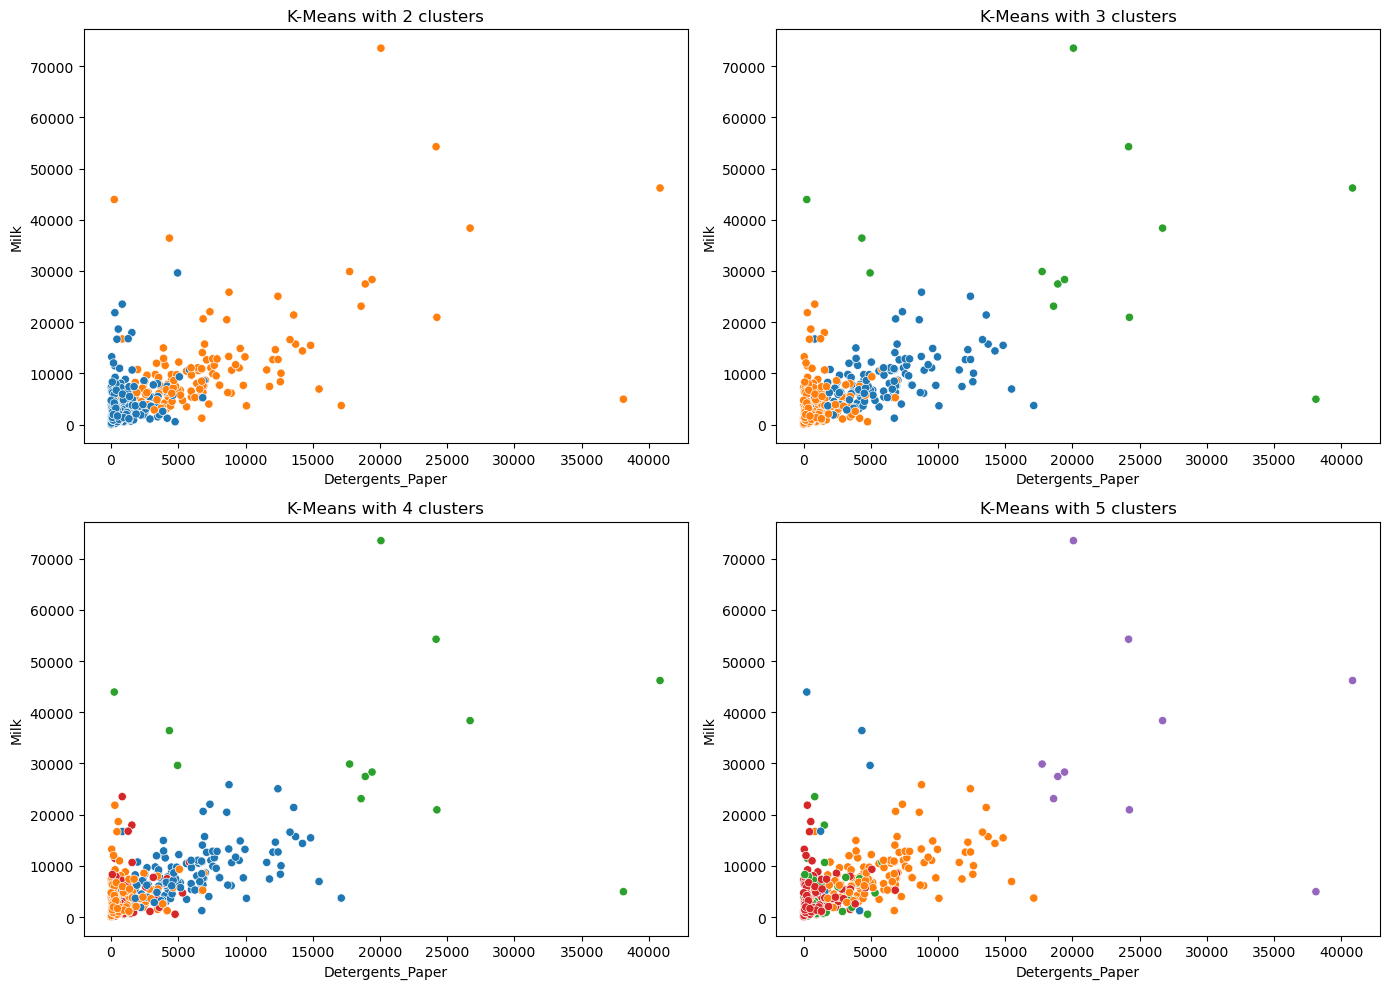

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, n_clusters in zip(axes.flatten(), [2, 3, 4, 5]):
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(customers_scale)
    sns.scatterplot(data=clean_customers, x='Detergents_Paper', y='Milk', hue=cluster_labels, palette='tab10', ax=ax, legend=False)
    ax.set_title(f'K-Means with {n_clusters} clusters')

plt.tight_layout()
plt.show()

**Your comment here**

- Two clusters gives the cleanest and most stable separation in the scatter plots.
- Three or more clusters start to split the large customer groups into smaller subgroups, but the extra clusters are less clearly separated.
- Based on the elbow plot and the visual comparison, `n_clusters=2` is the most convincing choice here.


# Bonus Challenge 3 - Changing DBSCAN `eps` and `min_samples`

Experiment changing the `eps` and `min_samples` params for DBSCAN. See how the results differ with scatter plot visualization.

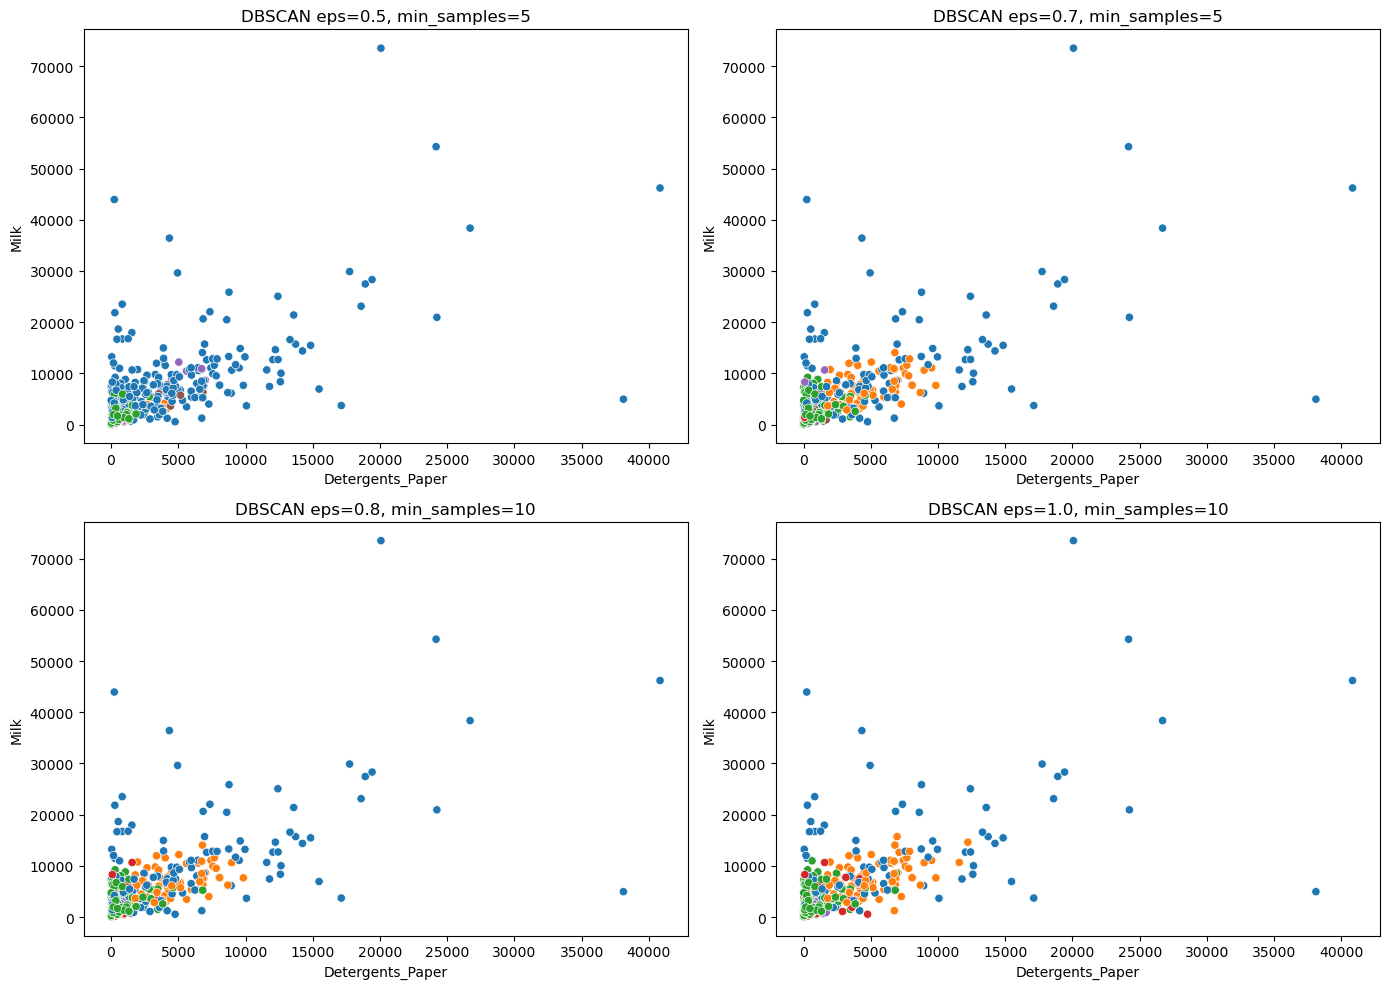

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
params = [(0.5, 5), (0.7, 5), (0.8, 10), (1.0, 10)]

for ax, (eps, min_samples) in zip(axes.flatten(), params):
    db = DBSCAN(eps=eps, min_samples=min_samples)
    db_labels = db.fit_predict(customers_scale)
    sns.scatterplot(data=clean_customers, x='Detergents_Paper', y='Milk', hue=db_labels, palette='tab10', ax=ax, legend=False)
    ax.set_title(f'DBSCAN eps={eps}, min_samples={min_samples}')

plt.tight_layout()
plt.show()

**Your comment here**

- DBSCAN is very sensitive to `eps` and `min_samples` on this dataset.
- Small `eps` values mark almost everything as noise, while larger values recover a few denser clusters.
- Even after tuning, DBSCAN is less stable and less interpretable here than K-Means, which is another sign that this dataset is not strongly density-clustered with the current feature representation.
